In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv(r"C:\Users\Junayed\pandas_prac\Aug_26\Cleaned_vet_data.csv")

In [21]:
df["VisitReason"].value_counts()

VisitReason
Checkup        19
Vaccination     9
Grooming        7
Surgery         6
Name: count, dtype: int64

In [52]:
df.loc[(df["Species"] == "Cat"), ["PatientID", "PetName", "OwnerName", "VisitReason"]].reset_index(drop=True).to_csv("cat_patient.csv", index=False)

In [54]:
df.loc[(df["Species"] == "Cat") & (df["Vaccinated"] == "No"), ["PatientID", "PetName", "OwnerName", "VisitReason", "Vaccinated"]].reset_index(drop=True)

,PatientID,PetName,OwnerName,VisitReason,Vaccinated
0,V003,Bella,Maria Chen,Grooming,No
1,V004,Charlie,Tom Reyes,Vaccination,No
2,V015,Leo,Chet Vance,Checkup,No
3,V018,Nala,Wendy Falk,Vaccination,No
4,V022,Shadow,Sonia Hollis,Checkup,No
5,V030,Molly,Reyna Novak,Vaccination,No
6,V039,Olive,Nadia Wren,Grooming,No
7,V042,Peanut,Owen Marsh,Checkup,No


In [56]:
df.loc[(df["Species"] == "Cat") & (df["Vaccinated"] == "No"), ["PatientID", "PetName", "OwnerName", "OwnerPhone","VisitReason", "Vaccinated"]].reset_index(drop=True).to_csv("not_vaccinated_cats.csv", index=False)

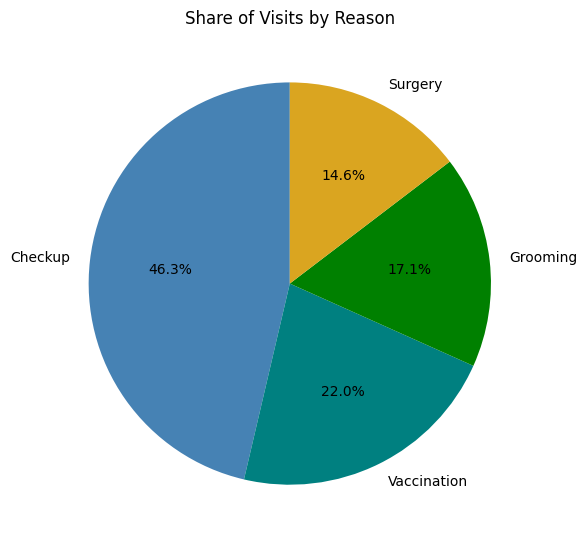

In [22]:
reason_counts = df["VisitReason"].value_counts()

plt.figure(figsize = (6,6))
plt.pie(reason_counts.values, labels= reason_counts.index,
autopct = '%1.1f%%',
        colors =["steelblue", "teal", "green", "goldenrod"],
        startangle=90)
plt.title("Share of Visits by Reason")
plt.tight_layout()
plt.savefig("visit_reasons_pie_chart.png", dpi=300, bbox_inches="tight")
plt.show()

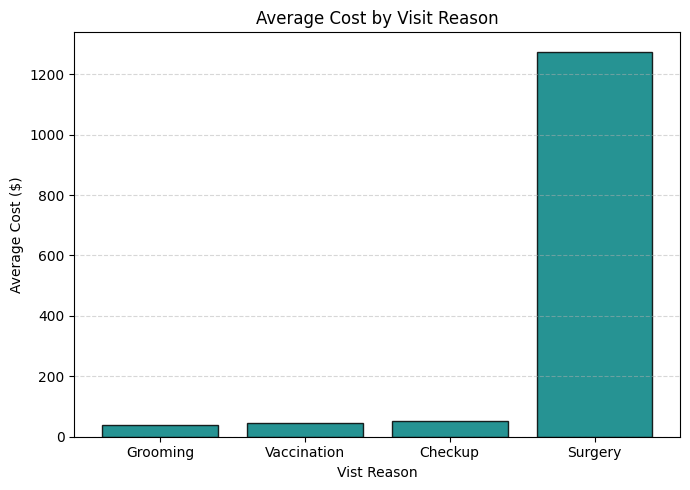

In [31]:
avg_cost = df.groupby("VisitReason")["Cost"].mean().sort_values()

plt.figure(figsize=(7,5))
plt.bar(avg_cost.index, avg_cost.values, color = "teal", edgecolor="black", alpha=0.85)
plt.title("Average Cost by Visit Reason")
plt.xlabel("Vist Reason")
plt.ylabel("Average Cost ($)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Average_cost_by_reason.png", dpi=300, bbox_inches = "tight")
plt.show()

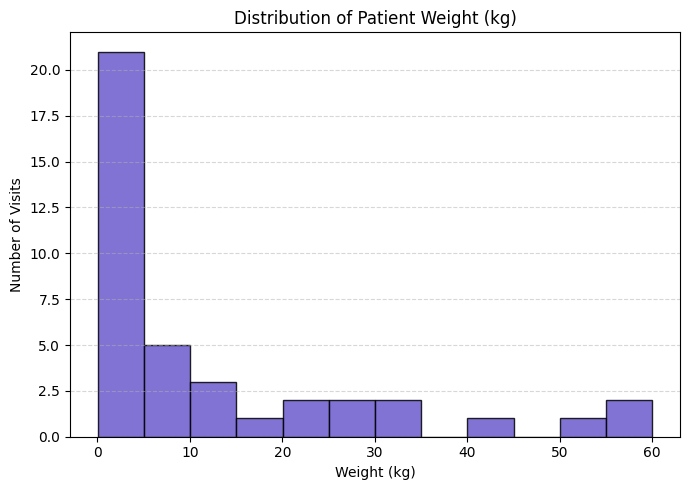

In [43]:
plt.figure(figsize=(7, 5))
plt.hist(df["WeightKg"].dropna(), bins=12, color="slateblue", edgecolor="black", alpha=0.85)
plt.grid(axis="y", linestyle = "--", alpha=0.5)
plt.title("Distribution of Patient Weight (kg)")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of Visits")
plt.tight_layout()
plt.savefig("Distribution_of_patient.png", dpi=300, bbox_inches = "tight")
plt.show()

In [34]:
df[["AgeYears", "WeightKg"]].corr()

,AgeYears,WeightKg
AgeYears,1.000000,0.461465
WeightKg,0.461465,1.000000


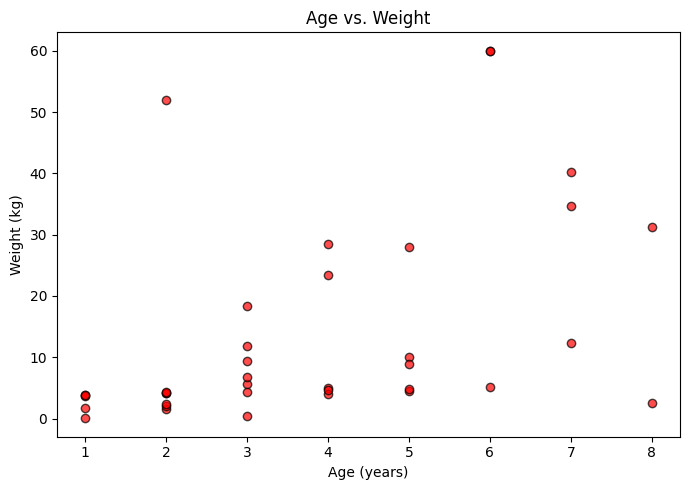

In [44]:
plt.figure(figsize=(7,5))
plt.scatter(df["AgeYears"], df["WeightKg"], alpha = 0.7, color="red", edgecolor = "black")
plt.title("Age vs. Weight")
plt.xlabel("Age (years)")
plt.ylabel("Weight (kg)")
plt.tight_layout()
plt.savefig("age_vs_weight_Scatter.png", dpi=300, bbox_inches = "tight")
plt.show()

In [38]:
pd.crosstab(df["Species"], df["Vaccinated"])

Vaccinated,No,Yes
Species,,
Bird,2,1
Cat,8,6
Dog,3,15
Rabbit,3,3


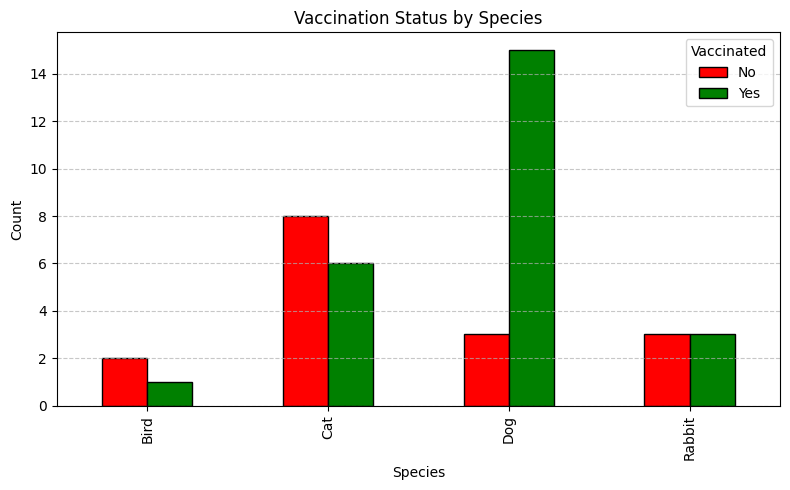

In [45]:
ct = pd.crosstab(df["Species"], df["Vaccinated"])
ct.plot(kind="bar", figsize=(8, 5), color=["red", "green"], edgecolor="black")
plt.title("Vaccination Status by Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.legend(title="Vaccinated")
plt.grid(axis="y", linestyle = "--", alpha = 0.7)
plt.tight_layout()
plt.savefig("vaccination_status_by_specis.png", dpi=300, bbox_inches = "tight")
plt.show()